# **Studi Kasus Machine Learning: Prediksi Penyakit Diabetes dengan Logistic Regression**

# library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, roc_auc_score

# Data Preparation

In [ ]:
# 1. Menyiapkan dataset
# Data awal
initial_data_diabetes = {
    'Usia': [45, 32, 50, 27, 60],
    'BMI': [28.5, 24.1, 30.2, 22.3, 26.7],
    'Tekanan_Darah': [120, 110, 130, 100, 140],
    'Gula_Darah': [180, 140, 200, 120, 210],
    'Riwayat_Keluarga': [1, 0, 1, 0, 1],
    'Diabetes': [1, 0, 1, 0, 1]
}

# Data tambahan
additional_data_diabetes = {
    'Usia': [40, 35, 55, 48, 52, 38, 29, 58, 42, 46],
    'BMI': [29.8, 25.4, 32.1, 27.6, 31.0, 30.5, 23.8, 34.2, 26.1, 28.9],
    'Tekanan_Darah': [125, 115, 135, 128, 132, 118, 105, 138, 121, 127],
    'Gula_Darah': [190, 145, 220, 175, 205, 185, 130, 230, 165, 195],
    'Riwayat_Keluarga': [1, 0, 1, 1, 0, 1, 0, 1, 1, 0],
    'Diabetes': [1, 0, 1, 1, 0, 1, 0, 1, 1, 0]
}

# Menggabungkan data
for col in initial_data_diabetes:
    initial_data_diabetes[col].extend(additional_data_diabetes[col])

df_db = pd.DataFrame(initial_data_diabetes)
print("Dataset:")
print(df_db)
print("\n")

Dataset:
    Usia   BMI  Tekanan_Darah  Gula_Darah  Riwayat_Keluarga  Diabetes
0     45  28.5            120         180                 1         1
1     32  24.1            110         140                 0         0
2     50  30.2            130         200                 1         1
3     27  22.3            100         120                 0         0
4     60  26.7            140         210                 1         1
5     40  29.8            125         190                 1         1
6     35  25.4            115         145                 0         0
7     55  32.1            135         220                 1         1
8     48  27.6            128         175                 1         1
9     52  31.0            132         205                 0         0
10    38  30.5            118         185                 1         1
11    29  23.8            105         130                 0         0
12    58  34.2            138         230                 1         1
13    42  2

# Exploratory Data Analysis

In [ ]:
# 2. EDA singkat
print("Statistik deskriptif:")
print(df_db.describe())
print("\n")

# Melihat korelasi antar fitur
correlation = df_db.corr()
print("Korelasi antar fitur:")
print(correlation['Diabetes'].sort_values(ascending=False))
print("\n")

# Visualisasi korelasi
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi antar Fitur')
plt.tight_layout()
plt.savefig('korelasi.png')
plt.close()

# Distribusi diabetes berdasarkan fitur
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Plot distribusi untuk setiap fitur
sns.boxplot(x='Diabetes', y='Usia', data=df_db, ax=axes[0])
axes[0].set_title('Usia vs Diabetes')

sns.boxplot(x='Diabetes', y='BMI', data=df_db, ax=axes[1])
axes[1].set_title('BMI vs Diabetes')

sns.boxplot(x='Diabetes', y='Tekanan_Darah', data=df_db, ax=axes[2])
axes[2].set_title('Tekanan Darah vs Diabetes')

sns.boxplot(x='Diabetes', y='Gula_Darah', data=df_db, ax=axes[3])
axes[3].set_title('Gula Darah vs Diabetes')

sns.countplot(x='Riwayat_Keluarga', hue='Diabetes', data=df_db, ax=axes[4])
axes[4].set_title('Riwayat Keluarga vs Diabetes')

axes[5].axis('off')  # Kosongkan subplot terakhir
plt.tight_layout()
plt.savefig('distribusi.png')
plt.close()

Statistik deskriptif:
            Usia        BMI  Tekanan_Darah  Gula_Darah  Riwayat_Keluarga  \
count  15.000000  15.000000      15.000000   15.000000         15.000000   
mean   43.800000  28.080000     122.933333  179.333333          0.600000   
std    10.310882   3.349883      11.822899   33.320236          0.507093   
min    27.000000  22.300000     100.000000  120.000000          0.000000   
25%    36.500000  25.750000     116.500000  155.000000          0.000000   
50%    45.000000  28.500000     125.000000  185.000000          1.000000   
75%    51.000000  30.350000     131.000000  202.500000          1.000000   
max    60.000000  34.200000     140.000000  230.000000          1.000000   

        Diabetes  
count  15.000000  
mean    0.600000  
std     0.507093  
min     0.000000  
25%     0.000000  
50%     1.000000  
75%     1.000000  
max     1.000000  


Korelasi antar fitur:
Riwayat_Keluarga    1.000000
Diabetes            1.000000
Gula_Darah          0.596068
Tekanan_Dar

In [ ]:
# 3. Preprocessing data
# Memisahkan fitur dan target
X = df_db.drop('Diabetes', axis=1)
y = df_db['Diabetes']

# Standardisasi fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data menjadi training dan testing (80:20)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
# 4. Hyperparameter Tuning Logistic Regression
param_grid = {'C': [0.01, 0.1, 1, 10, 100], 'solver': ['liblinear', 'lbfgs']}
log_reg = LogisticRegression(random_state=42, max_iter=1000)
grid_search = GridSearchCV(log_reg, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Menggunakan model terbaik
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


In [ ]:
# 5. Evaluasi Model
print("Akurasi Logistic Regression:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Akurasi Logistic Regression: 1.0
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3

Confusion Matrix:
[[2 0]
 [0 1]]


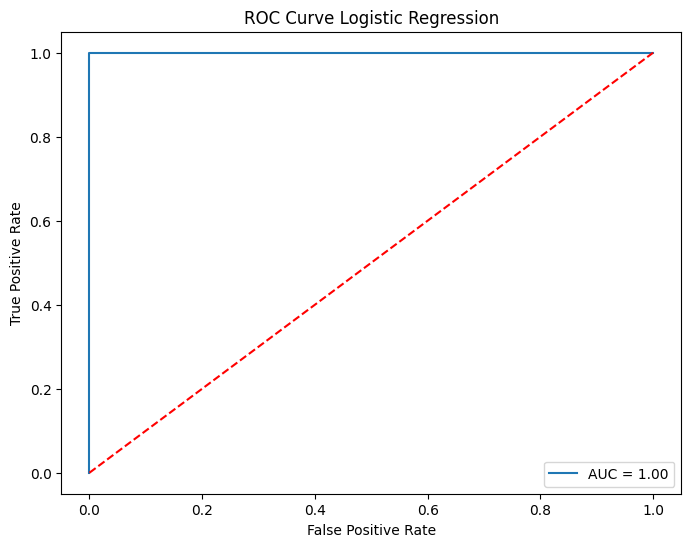

In [ ]:
# 6. ROC Curve dan AUC Score
y_probs = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Logistic Regression")
plt.legend()
plt.show()

Penjelasan ROC Curve dan AUC Score
1. ROC Curve (Receiver Operating Characteristic Curve)
ROC Curve adalah grafik yang menunjukkan trade-off antara True Positive Rate (TPR) dan False Positive Rate (FPR) pada berbagai ambang batas klasifikasi.

 - Sumbu X (False Positive Rate - FPR): Proporsi negatif yang salah diklasifikasikan sebagai positif.
 - Sumbu Y (True Positive Rate - TPR): Proporsi positif yang benar diklasifikasikan sebagai positif.
💡 Interpretasi:

  Jika kurva ROC mendekati pojok kiri atas, berarti model memiliki kinerja yang baik.
  Jika kurva dekat garis diagonal (y = x), berarti model hampir tidak lebih baik dari tebakan acak.

2. AUC Score (Area Under Curve)
AUC adalah nilai antara 0 dan 1 yang menunjukkan seberapa baik model membedakan kelas positif dan negatif.

 - AUC = 1.0 → Model sempurna.
 - AUC > 0.9 → Model sangat baik.
 - AUC 0.7 - 0.9 → Model cukup baik.
 - AUC 0.5 - 0.7 → Model kurang baik (hampir acak).
 - AUC < 0.5 → Model lebih buruk dari tebakan acak.

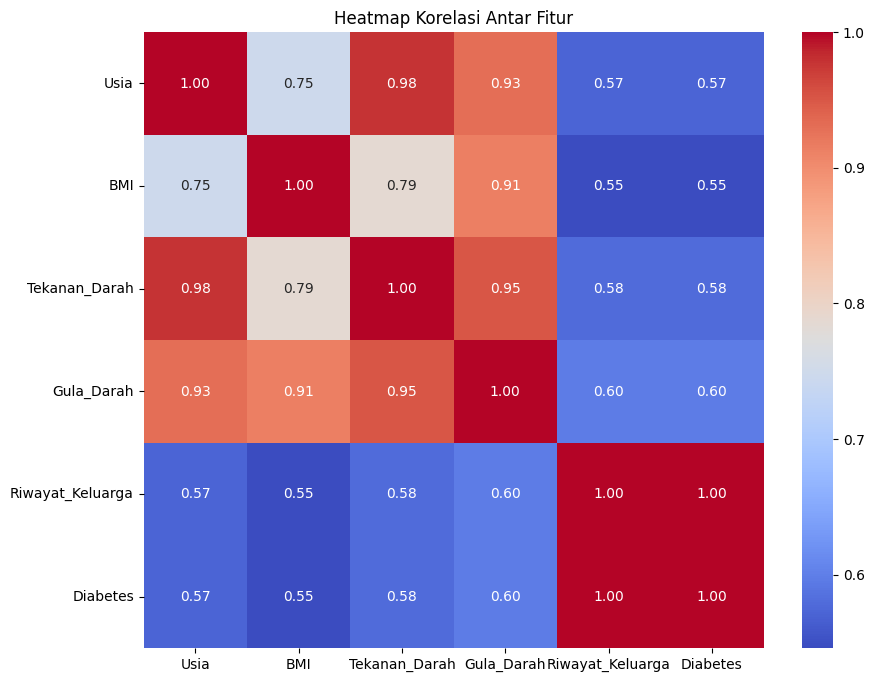

In [ ]:
# 7. Heatmap Korelasi
plt.figure(figsize=(10, 8))
sns.heatmap(df_db.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Heatmap Korelasi Antar Fitur")
plt.show()

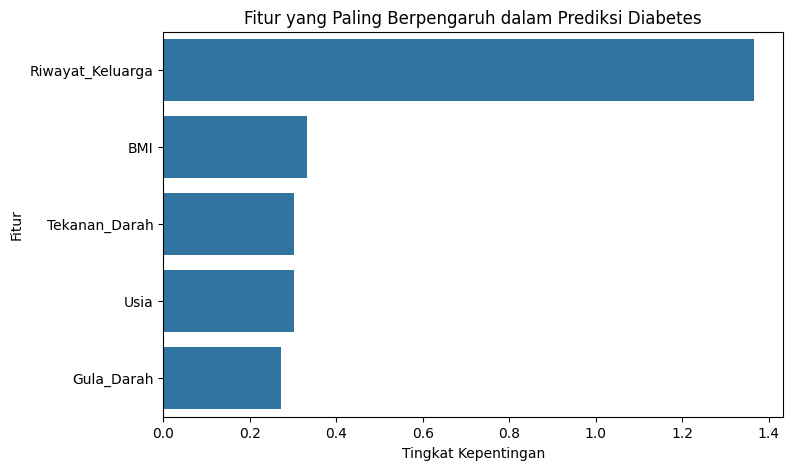


Fitur yang paling berpengaruh berdasarkan Logistic Regression:
Riwayat_Keluarga    1.365264
BMI                 0.332798
Tekanan_Darah       0.302843
Usia                0.301648
Gula_Darah          0.271549
dtype: float64


In [ ]:
# 8. Analisis Fitur yang Paling Berpengaruh
feature_importance = pd.Series(abs(model.coef_[0]), index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=feature_importance, y=feature_importance.index)
plt.xlabel("Tingkat Kepentingan")
plt.ylabel("Fitur")
plt.title("Fitur yang Paling Berpengaruh dalam Prediksi Diabetes")
plt.show()

print("\nFitur yang paling berpengaruh berdasarkan Logistic Regression:")
print(feature_importance)